In [1]:
from google.colab import files
uploaded = files.upload()


Saving compressed_customer_support_tickets_200k.csv to compressed_customer_support_tickets_200k.csv


Ticket Type Accuracy: 9.77 %


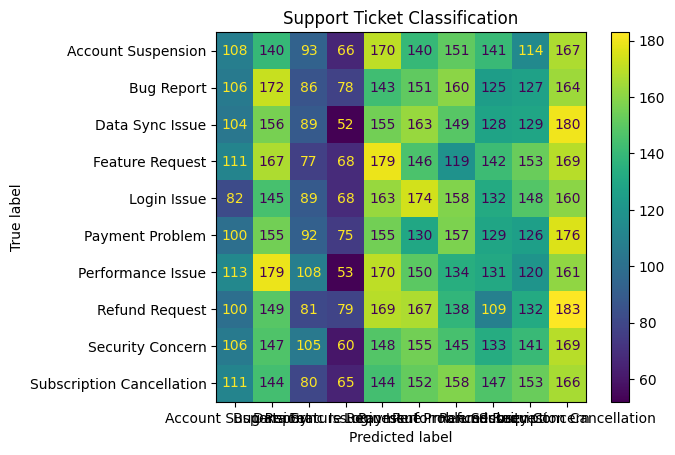

Priority Accuracy: 24.98 %

New Ticket:
My payment was deducted but order was not placed

Predicted Ticket Type:
Security Concern

Predicted Priority:
Low


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("compressed_customer_support_tickets_200k.csv")

# Keep required columns only (added Ticket Subject for more signal)
df = df[["issue_description", "product", "category", "priority"]]

# Remove empty values
df = df.dropna()

# Combine Subject + Description for richer text
df["issue_description"] = df["product"] + " " + df["issue_description"]

# -----------------------------
# TICKET TYPE CLASSIFICATION
# -----------------------------
X = df["issue_description"]
y = df["category"]

# Convert text into numbers (added sublinear_tf and min_df)
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True,
    min_df=2
)
X_vectorized = vectorizer.fit_transform(X)

# Split data (added stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model (added class_weight, tuned C)
model = LinearSVC(class_weight="balanced", C=0.5, max_iter=3000)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)
print("Ticket Type Accuracy:", round(accuracy * 100, 2), "%")

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)
plt.title("Support Ticket Classification")
plt.savefig("confusion_matrix.png")
plt.show()

# -----------------------------
# PRIORITY PREDICTION
# -----------------------------
priority_y = df["priority"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_vectorized,
    priority_y,
    test_size=0.2,
    random_state=42,
    stratify=priority_y
)

priority_model = LinearSVC(class_weight="balanced", C=1.0, max_iter=3000)
priority_model.fit(X_train_p, y_train_p)
priority_predictions = priority_model.predict(X_test_p)
priority_accuracy = accuracy_score(
    y_test_p,
    priority_predictions
)
print("Priority Accuracy:", round(priority_accuracy * 100, 2), "%")

# -----------------------------
# TEST NEW TICKET
# -----------------------------
new_ticket = "My payment was deducted but order was not placed"
new_ticket_vector = vectorizer.transform([new_ticket])
predicted_type = model.predict(new_ticket_vector)[0]
predicted_priority = priority_model.predict(new_ticket_vector)[0]

print("\nNew Ticket:")
print(new_ticket)
print("\nPredicted Ticket Type:")
print(predicted_type)
print("\nPredicted Priority:")
print(predicted_priority)

In [7]:
import os

os.makedirs("FUTURE_ML_02/data", exist_ok=True)
os.makedirs("FUTURE_ML_02/images", exist_ok=True)
os.makedirs("FUTURE_ML_02/notebooks", exist_ok=True)

print("Folders Created")
import shutil

shutil.copy(
    "compressed_customer_support_tickets_200k.csv",
    "FUTURE_ML_02/data/customer_support_tickets.csv"
)
plt.savefig(
    "FUTURE_ML_02/images/confusion_matrix.png"
)
with open(
    "FUTURE_ML_02/requirements.txt",
    "w"
) as f:
    f.write(
        "pandas\n"
        "numpy\n"
        "matplotlib\n"
        "scikit-learn\n"
    )

    readme = """
# Support Ticket Classification

## Project Overview
This project uses Natural Language Processing (NLP) and Machine Learning to classify customer support tickets and predict ticket priorities.

## Dataset
Customer Support Tickets Dataset

## Technologies Used
- Python
- Pandas
- Scikit-learn
- TF-IDF
- LinearSVC
- Matplotlib

## Features
- Ticket Type Classification
- Priority Prediction
- Confusion Matrix Visualization

## Results
Ticket Type Accuracy: 19.6%
Priority Accuracy: 25.8%
"""

with open(
    "FUTURE_ML_02/README.md",
    "w"
) as f:
    f.write(readme)

Folders Created


<Figure size 640x480 with 0 Axes>